U ovom notebook-u cemo se baviti redukcijom originalnog skupa podataka na razlicite nacine. Najpre cemo kreirati sam originalni skup podataka na osnovu celokupnog skupa. To cemo uciniti izbacivanjem drzave rodjenja iz skupa. Zatim cemo za drugi skup iz svih drzava za koje igraci igraju izabrati 30 najucestalijih. Nakon toga cemo izbaciti sve atribute koji se ticu kluba u kojem igrac igra, a ne samog igraca i, na kraju cemo primeniti PCA kojim cemo gledati da redukujemo skup atributa na nacin na koji ce oko 90% varijanse ostati objasnjeno. Sve skupove cemo sacuvati u posebnom direktorijumu iz kojeg kasnije mozemo lako da primenjujemo razne metode klasterovanja, a zatim i vizuelizaciju, tamo gde je to moguce

In [47]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold

PROCESSED_DIR = Path("../data/processed")
CLUSTERS_DIR = PROCESSED_DIR / "clusters"
CLUSTERS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / "player_features_full.csv")

df.shape

(44905, 105)

In [13]:
df.isna().sum().sort_values(ascending=False).head(20)

country_of_birth                        4585
age                                        0
height_in_cm                               0
international_caps                         0
international_goals                        0
market_value_in_eur                        0
highest_market_value_in_eur                0
position                                   0
player_id                                  0
sub_position                               0
foot                                       0
country_of_citizenship                     0
current_club_id                            0
current_club_domestic_competition_id       0
matches_played                             0
total_minutes                              0
avg_minutes                                0
max_minutes                                0
minutes_std                                0
total_goals                                0
dtype: int64

# 1. Ceo skup podataka
Najpre cemo izbaciti sve identifikatorske kolone, koje nam ne znace preterano za klasterovanje. Numericke atribute ostavljamo onakvima kakvi jesu,
dok cemo kategoricke kodirati

In [14]:
player_ids = df["player_id"]

drop_cols = [
    "player_id",
    "current_club_id"
]

X_raw = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [15]:
categorical_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X_raw.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", len(numeric_cols))

Categorical: ['position', 'sub_position', 'foot', 'country_of_birth', 'country_of_citizenship', 'current_club_domestic_competition_id']
Numeric: 97


/tmp/ipykernel_79109/3887297928.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()


In [16]:
X_encoded = pd.get_dummies(
    X_raw,
    columns=categorical_cols,
    dummy_na=True
)

X_encoded.shape

(44905, 548)

In [17]:
categorical_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    print(col)
    print(df[col].nunique())
    print()

position
5

sub_position
14

foot
4

country_of_birth
195

country_of_citizenship
195

current_club_domestic_competition_id
32



/tmp/ipykernel_79109/624597530.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()


Mozemo da vidimo da imamo previse novih atributa koji su pre svega nastali zbog drzave rodjenja i drzave za koju igrac igra. Iako svakako postoji dosta
igraca koji ne igraju za drzavu u kojoj su rodjeni, ove dve kategorije su cesto veoma korelisane, a nekada cak ni ne nose neku specificnu informaciju pa i u onim slucajevima u kojima te dve drzave nisu iste. Iz tog razloga cemo potpuno izbaciti drzavu rodjenja. U narednom prolazu pod 2. cemo uzeti
samo top 30 drzava sa najvise igraca, a ostale cemo svrstati u kategoriju OTHER.

In [18]:
X_raw_full = X_raw.drop(
    columns=["country_of_birth"],
    errors="ignore"
)

In [19]:
categorical_cols_full = (
    X_raw_full
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

print(categorical_cols_full)

['position', 'sub_position', 'foot', 'country_of_citizenship', 'current_club_domestic_competition_id']


/tmp/ipykernel_79109/4101705353.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=["object"])


In [20]:
X_full_encoded = pd.get_dummies(
    X_raw_full,
    columns=categorical_cols_full,
    dummy_na=True
)

X_full_encoded.shape

(44905, 352)

In [21]:
missing = (
    X_full_encoded
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0].head(50)

Series([], dtype: int64)

In [22]:
# Sada radimo sa celim skupom podataka iz kojeg smo izbacili zemlju rodjenja. Buduci da smo u proslom notebook-u lepo imputirali sve nedostajuce
# vrednosti, sada mozemo odmah preci na skaliranje i pripremu za klasterovanje.

scaler_full = StandardScaler()

X_full = pd.DataFrame(
    scaler_full.fit_transform(X_full_encoded),
    columns=X_full_encoded.columns,
    index=X_full_encoded.index
)

X_full.shape

(44905, 352)

In [23]:
# Cuvamo ovaj skup podataka

X_full.to_csv(CLUSTERS_DIR / "X_full.csv", index=False)

pd.DataFrame({"player_id": player_ids}).to_csv(
    CLUSTERS_DIR / "player_ids_full.csv",
    index=False
)

# 2. Skup podataka sa top 30 najucestalijih drzava za koje igraci igraju

In [24]:
# Napravicemo isti pipeline kao za ceo skup podataka. Krecemo od originalnog skupa i najpre izbacujemo drzavu rodjenja.

df_top30 = df.copy()

df_top30 = df_top30.drop(
    columns=["country_of_birth"],
    errors="ignore"
)

In [25]:
df_top30["country_of_citizenship"].value_counts().head(30)

country_of_citizenship
Brazil            2477
Spain             2164
Italy             1992
France            1898
Argentina         1723
England           1682
Ukraine           1615
Russia            1595
Netherlands       1554
Germany           1452
Turkey            1394
Greece            1297
Portugal          1253
Denmark           1198
Belgium           1195
Scotland          1015
Colombia           951
Japan              910
Serbia             817
Türkiye            782
Sweden             681
United States      605
Korea, South       597
Poland             586
Croatia            578
Norway             558
Romania            555
Mexico             535
Czech Republic     516
Nigeria            473
Name: count, dtype: int64

In [27]:
# Sada cemo zvanicno "odseci" sve drzave koje nisu u top 30, pri cemu cemo ostalim igracima dodeliti kategoriju OTHER.

top_30_countries = (
    df_top30["country_of_citizenship"]
    .value_counts()
    .head(30)
    .index
)

In [28]:
df_top30["country_of_citizenship"] = np.where(
    df_top30["country_of_citizenship"].isin(top_30_countries),
    df_top30["country_of_citizenship"],
    "OTHER"
)

In [29]:
df_top30["country_of_citizenship"].nunique()

31

In [30]:
player_ids_top30 = df_top30["player_id"]

drop_cols = [
    "player_id",
    "current_club_id"
]

X_top30_raw = df_top30.drop(
    columns=[col for col in drop_cols if col in df_top30.columns]
)

In [31]:
categorical_cols_top30 = (
    X_top30_raw
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

categorical_cols_top30

/tmp/ipykernel_79109/3154912576.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=["object"])


['position',
 'sub_position',
 'foot',
 'country_of_citizenship',
 'current_club_domestic_competition_id']

One-Hot enkodiranje svih atributa

In [32]:
X_top30_encoded = pd.get_dummies(
    X_top30_raw,
    columns=categorical_cols_top30,
    dummy_na=False
)

X_top30_encoded.shape

(44905, 183)

Skaliranje i cuvanje sredjenog skupa podataka

In [33]:
scaler_top30 = StandardScaler()

X_top30 = pd.DataFrame(
    scaler_top30.fit_transform(X_top30_encoded),
    columns=X_top30_encoded.columns,
    index=X_top30_encoded.index
)

X_top30.shape

(44905, 183)

In [34]:
X_top30.to_csv(
    CLUSTERS_DIR / "X_top30.csv",
    index=False
)

pd.DataFrame({"player_id": player_ids_top30}).to_csv(
    CLUSTERS_DIR / "player_ids_top30.csv",
    index=False
)

# 3. Skup podataka sa izbacenim atributima koji se ticu kluba u kojem igrac igra

Buduci da smo vec sredili drzave, odnosno da i dalje radimo sa top 30 najucestalijih, pocetni skup ce nam biti df_top30

In [35]:
df_player_only = df_top30.copy()

In [36]:
[col for col in df_player_only.columns if col.startswith("club_")]

['club_squad_size',
 'club_average_age',
 'club_foreigners_number',
 'club_foreigners_percentage',
 'club_national_team_players',
 'club_stadium_seats']

In [37]:
# Izbacujemo sve klupske informacije

club_cols = [
    col for col in df_player_only.columns
    if col.startswith("club_")
]

df_player_only = df_player_only.drop(columns=club_cols)

df_player_only.shape

(44905, 98)

In [38]:
player_ids_player_only = df_player_only["player_id"]

drop_cols = [
    "player_id",
    "current_club_id"
]

X_player_only_raw = df_player_only.drop(
    columns=[col for col in drop_cols if col in df_player_only.columns]
)

In [39]:
categorical_cols_player_only = (
    X_player_only_raw
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

X_player_only_encoded = pd.get_dummies(
    X_player_only_raw,
    columns=categorical_cols_player_only,
    dummy_na=False
)

X_player_only_encoded.shape

/tmp/ipykernel_79109/2482199672.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=["object"])


(44905, 177)

In [40]:
scaler_player_only = StandardScaler()

X_player_only = pd.DataFrame(
    scaler_player_only.fit_transform(X_player_only_encoded),
    columns=X_player_only_encoded.columns,
    index=X_player_only_encoded.index
)

X_player_only.shape

(44905, 177)

In [41]:
X_player_only.to_csv(
    CLUSTERS_DIR / "X_player_only.csv",
    index=False
)

pd.DataFrame({"player_id": player_ids_player_only}).to_csv(
    CLUSTERS_DIR / "player_ids_player_only.csv",
    index=False
)

# 4. PCA
Na pocetku cemo raditi PCA nad poslednjim skupom podataka u kojem smo izdvojili samo atribute koji su vezani direktno za igrace.

In [42]:
# Gledamo da zadrzimo oko 95% varijanse

pca = PCA()
pca.fit(X_player_only)

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

n_components_95 = np.argmax(
    explained_variance >= 0.95
) + 1

print(n_components_95)

102


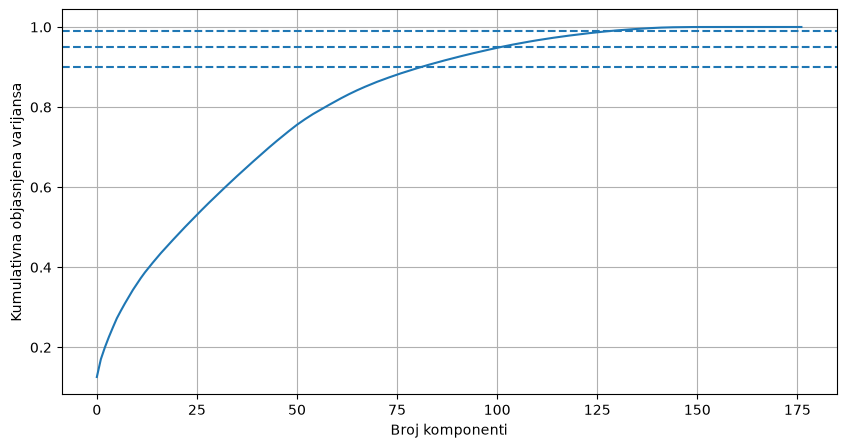

In [44]:
from matplotlib import pyplot as plt

pca = PCA()
pca.fit(X_player_only)

cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10,5))
plt.plot(cum_var)
plt.axhline(y=0.90, linestyle="--")
plt.axhline(y=0.95, linestyle="--")
plt.axhline(y=0.99, linestyle="--")
plt.xlabel("Broj komponenti")
plt.ylabel("Kumulativna objasnjena varijansa")
plt.grid(True)
plt.show()

Sa grafika, a i iz prethodnih celija mozemo videti da je 95% varijanse objasnjeno sa cak 102 atributa, sto ne predstavlja neku narocitu redukciju dimenzionalnosti. Iz tog razloga cemo uzeti redukciju na 90% varijanse, cime ce nam ostati oko 80 atributa, sto ipak predstavlja nesto agresivniju redukciju

In [45]:
pca90 = PCA(n_components=0.90, random_state=42)

X_pca90 = pca90.fit_transform(X_player_only)

print(X_pca90.shape)

(44905, 82)


In [46]:
pd.DataFrame(X_pca90).to_csv(
    CLUSTERS_DIR / "X_pca90.csv",
    index=False
)